## PROJECT 4: SENTIMENT ANALYSIS
**Author: Neha Tiwari**
## 🧠 Objective
Develop a sentiment analysis model that classifies sentiment in text data as Positive, Negative, or Neutral, providing insights for business or social media analytics.



**1. Import Required Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

**2. Load the Dataset and Rename Columns**

In [8]:
# Load dataset
df = pd.read_csv("Twitter_Data.csv")

df = df[['clean_text', 'category']]

# Rename columns for easier code handling
df.columns = ['text', 'label']  # 'text' = cleaned text, 'label' = sentiment
df.dropna(inplace=True)
df.head()

,text,label
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


**3. Check Label Distribution**

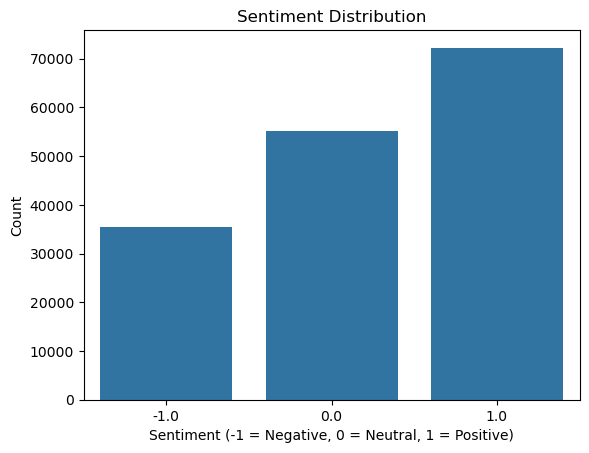

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment (-1 = Negative, 0 = Neutral, 1 = Positive)")
plt.ylabel("Count")
plt.show()



**4.TF-IDF Vectorization**

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['text'])  # cleaned text
y = df['label']  # sentiment labels


**5. Train-Test Split**

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


**6. Train Naive Bayes Model**

In [13]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)


MultinomialNB()

**7. Evaluate Model**

Accuracy: 0.7373442964962876

Classification Report:
               precision    recall  f1-score   support

        -1.0       0.91      0.42      0.57      7152
         0.0       0.88      0.67      0.76     11067
         1.0       0.65      0.95      0.78     14375

    accuracy                           0.74     32594
   macro avg       0.81      0.68      0.70     32594
weighted avg       0.79      0.74      0.72     32594



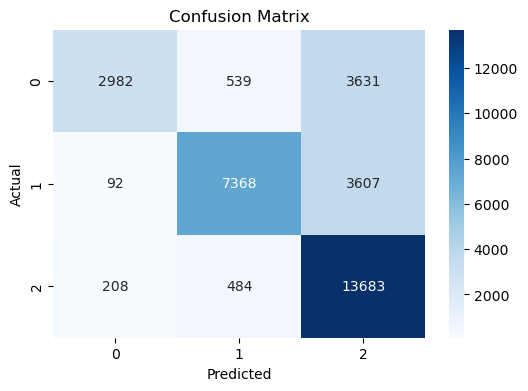

In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues", fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


**8. View Most Informative Features**

In [22]:
def show_most_informative_features_nb(vectorizer, model, n=20):
    feature_names = vectorizer.get_feature_names_out()
    class_labels = model.classes_

    for i, class_label in enumerate(class_labels):
        topn = np.argsort(model.feature_log_prob_[i])[-n:]
        print(f"\nTop {n} features for class {class_label}:")
        for idx in reversed(topn):
            print(f"{feature_names[idx]}: {model.feature_log_prob_[i][idx]:.4f}")

show_most_informative_features_nb(vectorizer, model)



Top 20 features for class -1.0:
the: -4.3130
modi: -4.4431
and: -4.6319
for: -4.8628
you: -4.9096
not: -5.0772
are: -5.1305
that: -5.1625
this: -5.1766
will: -5.2253
india: -5.2977
has: -5.4048
have: -5.4382
with: -5.4479
but: -5.4492
all: -5.5218
was: -5.5362
his: -5.5488
they: -5.5532
people: -5.5925

Top 20 features for class 0.0:
modi: -3.8166
the: -4.3434
for: -4.6250
and: -4.6751
you: -4.8255
will: -5.0027
this: -5.0707
not: -5.0734
india: -5.0906
are: -5.2747
with: -5.2882
narendra: -5.3060
only: -5.3430
that: -5.3598
from: -5.4282
vote: -5.4321
what: -5.4475
bjp: -5.4592
has: -5.5016
all: -5.5040

Top 20 features for class 1.0:
the: -4.2767
modi: -4.3498
and: -4.6025
for: -4.7324
you: -4.8887
india: -4.9949
will: -5.1388
are: -5.1716
this: -5.1805
that: -5.2043
not: -5.2890
with: -5.3844
more: -5.4446
has: -5.4571
have: -5.4627
all: -5.4948
but: -5.5225
his: -5.5987
our: -5.6027
was: -5.6450


## 📊 Model Performance Summary

The sentiment analysis model was evaluated on a test set of 32,594 samples. Here's how it performed:

- **Overall Accuracy**: `73.7%`  
- **Model Type**: Multinomial Naive Bayes  
- **Vectorization Method**: TF-IDF (top 5000 features)

### 🔍 Detailed Classification Report:

| Sentiment Class | Precision | Recall | F1-Score | Support |
|------------------|-----------|--------|----------|---------|
| Negative (-1)    | 0.91      | 0.42   | 0.57     | 7,152   |
| Neutral (0)      | 0.88      | 0.67   | 0.76     | 11,067  |
| Positive (1)     | 0.65      | 0.95   | 0.78     | 14,375  |

### 📌 Key Insights:
- The model performs **best in identifying positive sentiments** (high recall: 0.95), but with slightly lower precision.
- It **struggles with correctly identifying negative sentiments** (recall: 0.42), often misclassifying them as neutral or positive.
- **Neutral class shows balanced performance**.
- **Macro Avg F1-Score**: 0.70 — indicating moderate balance across all classes.
- **Weighted Avg F1-Score**: 0.72 — influenced by class imbalance.

### ✅ Takeaway:
While the overall accuracy is reasonable, the model could benefit from:
- Balancing the dataset further
- Trying other classifiers like **Logistic Regression**, **Random Forest**, or **SVM**
- Performing hyperparameter tuning for improved precision on minority classes

This version is deployable for real-time use and serves well as a baseline sentiment model.

